In [1]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.common import *
from src.pipeline import *

In [2]:
RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

train_dataset, test_dataset = get_mnist()
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [3]:
df = run_grid_experiments(
    train_dataset=train_dataset,
    test_loader=test_loader,
    batch_sizes=[1, 4, 8, 16],
    sigmas=[0.0, 0.01, 0.05, 0.1],
    seeds=[0, 1, 2],
)

df.to_csv(os.path.join(RESULTS_DIR, "mnist_dp_batchsize_tradeoff.csv"), index=False)
df.head()

iter=20: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=40: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: loss did not improve in the last 50 rounds.
iter=20: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=40: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=57: loss did not improve in the last 50 rounds.
iter=20: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=40: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=58: loss did not improve in the last 50 rounds.
communication 0, epoch 0: client-1 2.212738513946533
iter=20: 116.21176147460938, (best_iter=2: 6.575657844543457)
iter=40: 116.21176147460938, (best_iter=2: 6.575657844543457)
iter=53: loss did not improve in the last 50 rounds.
communication 0, epoch 0: client-1 2.1215672492980957
iter=20: 153.69459533691406, (best_iter=2: 6.643543243408203)
iter=40: 153

,dataset_name,model_name,activation,num_clients,clients_per_round,num_rounds,local_epochs,batch_size,client_lr,use_dp,...,attack_lr,attack_distance,secret_index,seed,noniid_alpha,secret_pos,test_loss,test_acc,attack_mse,attack_ssim
0,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,False,...,1.0,l2,7,0,None,0,13.228685,0.101,1.555841e-06,0.999885
1,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,False,...,1.0,l2,7,1,None,0,11.909290,0.101,5.756340e-07,0.999911
2,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,False,...,1.0,l2,7,2,None,0,12.215744,0.101,1.995473e-06,0.999847
3,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,True,...,1.0,l2,7,0,None,0,2.443177,0.101,5.244315e+03,-0.000014
4,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,True,...,1.0,l2,7,1,None,0,2.467926,0.101,5.975145e+02,-0.000091


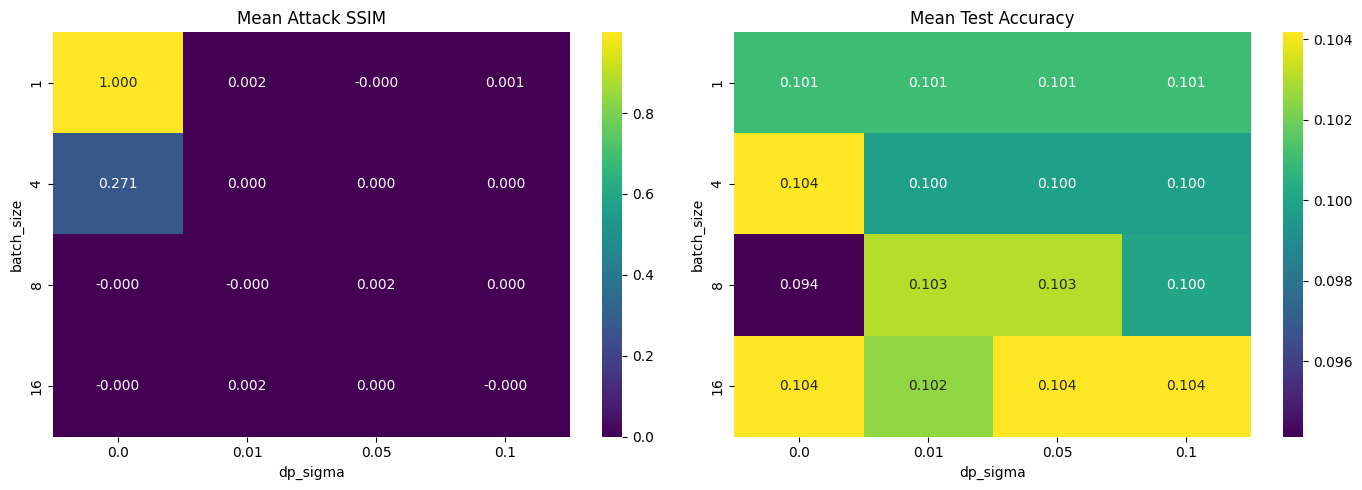

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

summary_df = df.groupby(["batch_size", "dp_sigma"]).agg({
    "attack_ssim": ["mean", "std"],
    "test_acc": ["mean", "std"]
}).reset_index()

summary_df.columns = [
    "_".join(col).strip() if col[1] else col[0]
    for col in summary_df.columns.values
]
summary_df = summary_df.rename(columns={"batch_size_": "batch_size", "dp_sigma_": "dp_sigma"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ssim_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="attack_ssim_mean")
sns.heatmap(ssim_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Mean Attack SSIM")

acc_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="test_acc_mean")
sns.heatmap(acc_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title("Mean Test Accuracy")

plt.tight_layout()
plt.show()

In [5]:
summary_df["privacy_score"] = 1 - summary_df["attack_ssim_mean"]

summary_df["tradeoff_score"] = (
    0.5 * summary_df["privacy_score"] +
    0.5 * summary_df["test_acc_mean"]
)


In [6]:
ranking_df = summary_df.sort_values("tradeoff_score", ascending=False).reset_index(drop=True)
ranking_path = os.path.join(RESULTS_DIR, "mnist_tradeoff_ranking.csv")
ranking_df.to_csv(ranking_path, index=False)

print("Top configurations by trade-off score:")
display(ranking_df[[
    "batch_size",
    "dp_sigma",
    "attack_ssim_mean",
    "test_acc_mean",
    "privacy_score",
    "tradeoff_score"
]].head(10))

Top configurations by trade-off score:


,batch_size,dp_sigma,attack_ssim_mean,test_acc_mean,privacy_score,tradeoff_score
0,16,0.00,-1.763339e-05,0.104167,1.000018,0.552092
1,16,0.10,-1.077102e-05,0.104167,1.000011,0.552089
2,16,0.05,2.877440e-04,0.104167,0.999712,0.551939
3,8,0.01,-7.305230e-05,0.103033,1.000073,0.551553
4,1,0.05,-1.363130e-05,0.101000,1.000014,0.550507
5,16,0.01,1.883695e-03,0.102500,0.998116,0.550308
6,8,0.05,2.455695e-03,0.103033,0.997544,0.550289
7,1,0.10,8.510434e-04,0.101000,0.999149,0.550074
8,8,0.10,1.231992e-05,0.100033,0.999988,0.550011
9,4,0.01,1.772408e-07,0.099800,1.000000,0.549900


In [7]:
ssim_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="attack_ssim_mean")
acc_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="test_acc_mean")
tradeoff_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="tradeoff_score")

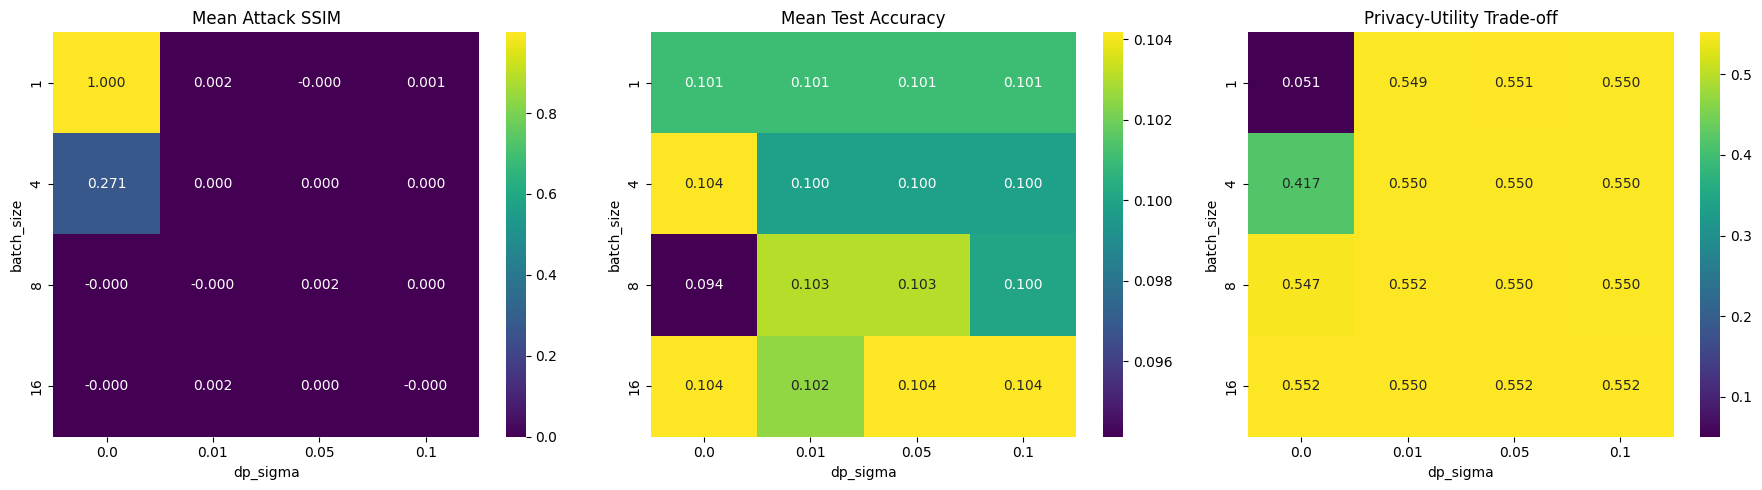

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(ssim_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Mean Attack SSIM")

sns.heatmap(acc_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title("Mean Test Accuracy")

sns.heatmap(tradeoff_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[2])
axes[2].set_title("Privacy-Utility Trade-off")

for ax in axes:
    ax.set_xlabel("dp_sigma")
    ax.set_ylabel("batch_size")

plt.tight_layout()

In [9]:
plot_path = os.path.join(RESULTS_DIR, "mnist_tradeoff_heatmaps.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved ranking to: {ranking_path}")
print(f"Saved figure to: {plot_path}")

<Figure size 640x480 with 0 Axes>

Saved ranking to: ../results/mnist_tradeoff_ranking.csv
Saved figure to: ../results/mnist_tradeoff_heatmaps.png
